# 02_01. 순환소수 프랙탈 & 지수적 성장 샌드박스 (Recurring Decimal Fractal & Exponent Sandbox)

> **수학선생님의 깊이 있는 사유와 시각화 가이드**
>
> _"끝없이 펼쳐지는 무한의 방랑 속에서 본질의 비율을 찾아내고, 지수의 벼벼진 거듭제곱 속에 깃든 우주의 팽창 법칙을 만져봅니다."_

이 노트북은 중학교 2학년 **'수와 식의 계산'** 단원의 핵심 개념 두 가지를 직관적으로 체험하기 위해 설계되었습니다.

1. **실습 1: 순환소수 나선형 스펙트럼 (Recurring Decimal Fractal)**
   - 분수를 소수로 바꿀 때 발생하는 나눗셈의 나머지(Remainder)들이 그리는 기하학적 순환 루프를 시각화합니다. 영원히 끝나지 않을 것 같은 무한소수의 혼돈 속에 내재된 완벽한 기하적 질서와 대칭성을 관찰합니다.
2. **실습 2: 지수의 폭발성 샌드박스 (Exponential Growth Sandbox)**
   - 세포 분열 및 복리의 예시를 바탕으로, 선형(Linear) 성장과 지수(Exponential) 성장의 엄청난 격차를 대화형 슬라이더로 조절하며 관찰합니다. Y축을 선형 스케일과 로그 스케일로 대조하여 지수의 마법을 이해합니다.

---
## 실습 1. 순환소수 나선형 스펙트럼 (Recurring Decimal Fractal)

유리수 $\frac{p}{q}$를 소수로 변환할 때, 우리는 분모 $q$로 끊임없이 나눗셈을 수행합니다. 이때 발생하는 **나머지(Remainder)**는 항상 $q$보다 작은 정수들($0, 1, 2, \dots, q-1$) 중 하나입니다.

만약 나누어떨어지지 않는다면(순환소수라면), 비둘기집 원리에 의해 언젠가는 반드시 이전에 나왔던 나머지가 다시 등장하게 되고, 그 순간부터 동일한 숫자 배열이 무한히 되풀이되는 **순환마디**가 형성됩니다.

우리는 각 나눗셈 단계 $k$에서 발생하는 나머지 $R_k$를 극좌표계(Polar Coordinate)의 각도와 반지름에 대응시켜 **기하학적 순환 궤적**을 시각화합니다.
- **각도 $\theta_k$**: 나머지 값에 대응하는 각도 $R_k \times \frac{2\pi}{q}$
- **반지름 $r_k$**: 단계의 진행에 비례하여 밖으로 뻗어나가는 나선 궤적 $1.0 + k \times \Delta r$
- **색상 흐름**: 파란색(`Blue #0B79D0`)에서 초록색(`Green #2FA85D`)으로 서서히 변하는 그라데이션을 적용하여 순환 흐름의 방향성을 보여줍니다.

In [1]:
# =====================================================================
# [실습 1 - 도구 준비 셀] 라이브러리 로드 및 한글 폰트/마이너스 깨짐 설정
# =====================================================================

# 수치 연산 및 기하 데이터 생성을 위한 NumPy 라이브러리 가져오기
import numpy as np

# 수학적 시각화 및 극좌표 그래프 표현을 위한 Matplotlib 라이브러리 가져오기
import matplotlib.pyplot as plt

# 슬라이더 및 대화형 UI를 구축하여 동적 시뮬레이션을 가능케 하는 ipywidgets 라이브러리 가져오기
import ipywidgets as widgets
from ipywidgets import interact, interactive, fixed

# 시스템 폰트 설정을 제어하여 한글 깨짐을 방지하기 위한 OS 및 font_manager 로드
import os
import matplotlib.font_manager as fm

# macOS 환경(AppleGothic)과 Windows 환경(Malgun Gothic)을 상호 지원하여 한글 폰트를 매끄럽게 적용
import platform
if platform.system() == 'Darwin':  # macOS의 경우
    plt.rc('font', family='AppleGothic')
elif platform.system() == 'Windows':  # Windows의 경우
    plt.rc('font', family='Malgun Gothic')
else:  # 리눅스/기타 환경의 경우 기본 무설치 폰트나 시스템 대표 폰트 설정
    plt.rc('font', family='DejaVu Sans')

# 마이너스 기호(-)가 깨지는 현상을 방지하기 위해 유니코드 마이너스 사용 해제 설정
plt.rcParams['axes.unicode_minus'] = False

print("실습 1을 위한 모든 수학 라이브러리 및 폰트 세팅이 완료되었습니다.")

실습 1을 위한 모든 수학 라이브러리 및 폰트 세팅이 완료되었습니다.


In [2]:
# =====================================================================
# [실습 1 - 수학 데이터 생성 셀] 나눗셈 알고리즘 및 순환마디 감지 함수 정의
# =====================================================================

def analyze_recurring_decimal(p, q, max_steps=1000):
    """
    분수 p/q (단, p < q)를 입력받아 직접 나눗셈을 수행하면서 
    소수점 아래 자리들과 나눗셈 과정의 나머지(Remainder) 수열을 추적하고,
    순환마디의 시작점 및 길이를 계산하는 핵심 수학적 함수입니다.
    """
    # 기약분수 처리를 위해 약분하지 않고, 나눗셈이 일어나는 물리적 현상을 그대로 추적합니다.
    remainders = []   # 각 나눗셈 단계에서 생기는 나머지를 순서대로 저장하는 리스트
    digits = []       # 소수점 아래로 몫으로 떨어지는 소수 자리 숫자 리스트
    
    # 특정 나머지가 몇 번째 인덱스(단계)에서 처음 발견되었는지 기록하여 
    # 중복된 나머지가 나타나는 시점(순환 루프의 닫힘)을 실시간으로 감지하기 위한 딕셔너리
    rem_to_position = {}
    
    current = p       # 나눗셈의 피제수(Numerator/Remainder)의 시작
    cycle_start = -1  # 순환마디가 시작되는 인덱스 (기본값 -1: 유한소수)
    
    # 최대 시뮬레이션 단계(max_steps) 동안 나눗셈을 반복적으로 실행
    for step in range(max_steps):
        current *= 10             # 분수에 10을 곱해 소수점 아래 자리수로 이동
        digit = current // q      # 현재 몫의 한 자리 숫자
        rem = current % q         # 나눗셈을 하고 남은 나머지
        
        # 소수점 한 자리의 결과와 나머지를 차곡차곡 리스트에 담음
        digits.append(digit)
        remainders.append(rem)
        
        # 나머지가 0이 되면 소수점 아래 나눗셈이 종료되어 유한소수가 됨
        if rem == 0:
            break
            
        # 만약 현재 나머지가 이전에 이미 등장한 적이 있다면 순환마디 발견!
        if rem in rem_to_position:
            cycle_start = rem_to_position[rem]
            break
            
        # 아직 나타난 적 없는 나머지라면 현재 위치(인덱스)를 기록
        rem_to_position[rem] = step
        
        # 나머지를 다음 단계의 피제수로 지정하여 나눗셈을 지속
        current = rem
        
    return digits, remainders, cycle_start

# 1/7 분수를 테스트로 실행하여 정상적으로 나머지가 연산되는지 디버깅 출력
test_digits, test_rems, test_start = analyze_recurring_decimal(1, 7)
print("분수 1/7 분석 결과:")
print(f" - 소수점 아래 자리수: {test_digits}")
print(f" - 나머지(Remainder) 수열: {test_rems}")
print(f" - 순환마디 시작 단계: {test_start} (값: {test_rems[test_start] if test_start != -1 else '없음'})")

분수 1/7 분석 결과:
 - 소수점 아래 자리수: [1, 4, 2, 8, 5, 7, 1]
 - 나머지(Remainder) 수열: [3, 2, 6, 4, 5, 1, 3]
 - 순환마디 시작 단계: 0 (값: 3)


findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 400.


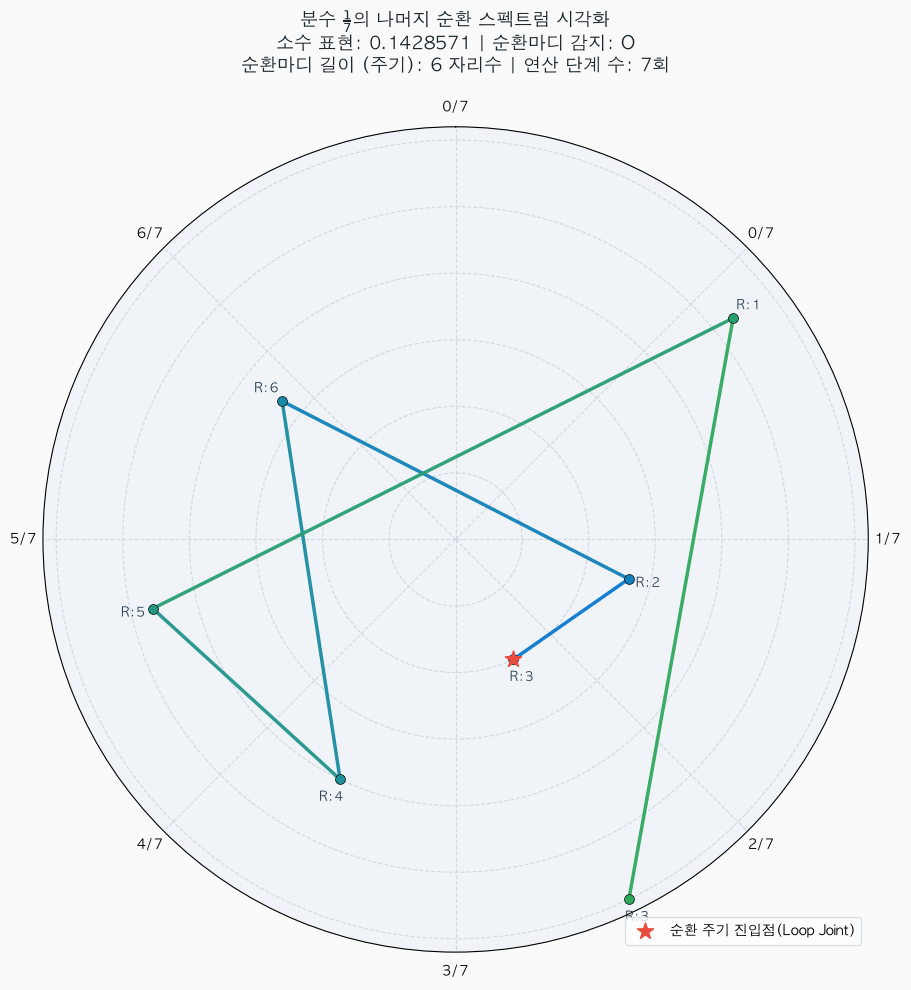

In [3]:
# =====================================================================
# [실습 1 - 시각화 렌더링 셀] 극좌표계 기반 나머지 전이 나선 시각화 함수 정의
# =====================================================================

def plot_recurring_spiral(p, q):
    """
    분수 p/q의 나머지 수열 데이터를 극좌표 궤적과 그라데이션 라인으로 렌더링합니다.
    """
    # 1. 수학적 연산 수행
    digits, rems, cycle_start = analyze_recurring_decimal(p, q, max_steps=200)
    n_points = len(rems)
    
    # 2. 그림 생성 (상황실의 Mission Control 컨셉을 반영한 세련된 배치)
    fig = plt.figure(figsize=(10, 10), facecolor='#FAFAFA')
    ax = fig.add_subplot(111, polar=True)
    ax.set_facecolor('#F0F4F8')  # 연한 블루 그레이 톤으로 세련된 기하 패널 구성
    ax.grid(True, color='#D0D9E0', linestyle='--', linewidth=0.8)
    
    # 3. 극좌표 상의 점(Angle, Radius) 매핑 데이터 생성
    # 각 각도(theta)는 나머지 크기에 정비례하게 설계: R_k * 2pi / q
    theta = np.array([r * 2 * np.pi / q for r in rems])
    
    # 반지름(radius)은 나선 형태로 밖으로 퍼지도록 설계하여 중첩을 방지하고 시간의 흐름(단계)을 표현
    # r_k = 1.0 + k * (2.0 / n_points)
    radius = np.linspace(1.0, 3.0, n_points)
    
    # 4. 파란색(#0B79D0)에서 초록색(#2FA85D)으로 흐르는 HSL 형태의 그라데이션 선 그리기
    for i in range(n_points - 1):
        # 진행도에 따라 RGB 색상 보간 계산 (t = 0.0일 때 파랑, t = 1.0일 때 초록)
        t = i / max(1, n_points - 2)
        color = (1.0 - t) * np.array([11/255, 121/255, 208/255]) + t * np.array([47/255, 168/255, 93/255])
        
        # 각 세그먼트 선분을 순서대로 플로팅
        ax.plot(theta[i:i+2], radius[i:i+2], color=color, linewidth=2.5, alpha=0.95)
    
    # 5. 각 나눗셈 단계별 점(Node) 표시 및 텍스트 마킹
    # 스텝 수가 적을 때(가시성이 확보될 때만) 각 노드의 나머지 값(Remainder)을 라벨로 표시
    for i in range(min(n_points, 40)):
        t = i / max(1, n_points - 1)
        color = (1.0 - t) * np.array([11/255, 121/255, 208/255]) + t * np.array([47/255, 168/255, 93/255])
        
        # 노드 점 표시
        ax.scatter(theta[i], radius[i], color=color, s=50, zorder=5, edgecolors='black', linewidths=0.5)
        
        # 첫 몇 개 노드 옆에 나머지 값(R_i) 텍스트 주석 표시
        if n_points <= 30:
            ax.text(theta[i], radius[i] + 0.15, f"R:{rems[i]}", fontsize=9, 
                    color='#2C3E50', weight='bold', ha='center', va='center')
            
    # 6. 순환마디가 검출된 경우, 순환 시작점을 빨간색 원 및 가이드 선으로 표시하여 시각적 통찰 제공
    if cycle_start != -1:
        ax.scatter(theta[cycle_start], radius[cycle_start], color='#E74C3C', s=150, 
                   zorder=6, marker='*', label='순환 주기 진입점(Loop Joint)')
        
    # 7. 극좌표 축 가독성 설정 (각도 라벨을 분모 q에 대응하도록 정수 비율로 표현)
    ax.set_theta_zero_location('N')  # 12시 방향을 0(북쪽)으로 고정하여 나눗셈의 시작점으로 정의
    ax.set_theta_direction(-1)       # 시계 방향으로 각도가 커지도록 회전 방향을 고정
    
    # 각도 라벨을 8방위 정렬
    theta_ticks = np.linspace(0, 2*np.pi, 8, endpoint=False)
    ax.set_xticks(theta_ticks)
    ax.set_xticklabels([f"{int(tick*q/(2*np.pi))}/{q}" for tick in theta_ticks], fontsize=10, weight='bold')
    
    # 반지름 가이드 선 제거하여 복잡하지 않고 세련된 기하학적 형태만 강조
    ax.set_yticklabels([])
    
    # 8. 소수점 아래 정보 및 분석 텍스트 헤더 생성
    cycle_len = len(rems) - 1 - cycle_start if cycle_start != -1 else 0
    decimal_str = "0." + "".join(map(str, digits[:15])) + ("..." if len(digits) > 15 else "")
    
    title_str = (f"분수 $\\frac{{{p}}}{{{q}}}$의 나머지 순환 스펙트럼 시각화\n"
                 f"소수 표현: {decimal_str} | "
                 f"순환마디 감지: {'O' if cycle_start != -1 else 'X (유한소수)'}\n"
                 f"순환마디 길이 (주기): {cycle_len} 자리수 | 연산 단계 수: {n_points}회")
    
    plt.title(title_str, fontsize=13, weight='bold', color='#1A252C', pad=20)
    if cycle_start != -1:
        plt.legend(loc='lower right', frameon=True, facecolor='#FFFFFF', edgecolor='#D0D9E0')
        
    plt.tight_layout()
    plt.show()

# 테스트 호출
plot_recurring_spiral(1, 7)

In [ ]:
# =====================================================================
# [실습 1 - 인터랙티브 대시보드 셀] 슬라이더 위젯 생성 및 연결
# =====================================================================

# ipywidgets의 interact 함수를 이용해 분자(p)와 분모(q)를 실시간 조절
# 분자는 1부터 49까지, 분모는 분자보다 큰 값(2부터 150까지)으로 가변적으로 설정
interact(
    plot_recurring_spiral, 
    p=widgets.IntSlider(min=1, max=50, step=1, value=1, description='분자 (p):', continuous_update=False),
    q=widgets.IntSlider(min=2, max=150, step=1, value=7, description='분모 (q):', continuous_update=False)
);

interactive(children=(IntSlider(value=1, continuous_update=False, description='분자 (p):', max=50, min=1), IntSl…

---
## 실습 2. 지수의 마법: 선형 vs 지수적 성장 샌드박스 (Exponential Growth Sandbox)

우리는 일상생활에서 매일 고정된 양이 더해지는 **선형적(Linear) 성장**과, 일정한 비율만큼 곱해지는 **지수적(Exponential) 성장**을 마주합니다.

이 두 성장의 수학적 모델은 다음과 같습니다:
- **선형 성장 (Linear Growth)**: $y(t) = a + m \cdot t$
  - 매 단계마다 기울기(증가량) $m$이 누적해서 **더해집니다**.
- **지수 성장 (Exponential Growth)**: $y(t) = a \cdot b^t$ (또는 $a \cdot (1 + r)^t$)
  - 매 단계마다 밑(성장배수) $b$가 곱해져 **기하급수적으로 폭발**합니다.

이 샌드박스에서는 세포 자가 분열(매 회 2배씩 분열, $b=2$)과 금융의 복리 자산 증가(연 이율 $r$, $b = 1+r$)라는 두 가지 현실적인 시나리오를 바탕으로 두 성장의 궤적 차이를 극명하게 시각화합니다.

특히, 일반 스케일(Linear Scale)과 로그 스케일(Logarithmic Scale) 그래프를 나란히 배치하여, 로그 연산이 폭발하는 지수 스케일을 어떻게 선형적인 질서로 차분히 수렴시켜 보여주는지 관찰합니다.

In [9]:
# =====================================================================
# [실습 2 - 도구 준비 셀] 라이브러리 로드 및 한글/마이너스 폰트 설정 (독립성 보장)
# =====================================================================

# 수치 계산 및 범위 데이터 생성을 위한 NumPy 임포트
import numpy as np

# 2D 평면 플로팅 및 그래프 렌더링을 위한 Matplotlib.pyplot 임포트
import matplotlib.pyplot as plt

# 슬라이더 인터랙션 UI를 구축하기 위한 ipywidgets 로드
import ipywidgets as widgets
from ipywidgets import interact

# 한글 깨짐 방지 폰트 환경 검출 및 전역 폰트 재정의
import platform
if platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')
elif platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
else:
    plt.rc('font', family='DejaVu Sans')

# 유니코드 마이너스 인코딩 오류 해제
plt.rcParams['axes.unicode_minus'] = False

print("실습 2를 위한 모든 수학 라이브러리 및 독립 실행 폰트 세팅이 완료되었습니다.")

실습 2를 위한 모든 수학 라이브러리 및 독립 실행 폰트 세팅이 완료되었습니다.


In [10]:
# =====================================================================
# [실습 2 - 수학적 데이터 생성 셀] 선형 및 지수 성장 함수 공식화
# =====================================================================

def generate_growth_data(initial_val, linear_rate, exp_rate, duration, mode='finance'):
    """
    선택한 모드('finance': 복리 자산, 'biology': 세포 분열)에 맞추어
    시간 t의 흐름에 따른 선형 성장과 지수 성장 데이터를 생성하는 함수입니다.
    """
    # 시간(t)축 생성: 0부터 duration(기간)까지 정수 간격으로 세대/시간 생성
    t = np.arange(0, duration + 1)
    
    if mode == 'biology':
        # 생물학 세포 분열 모드: 매 단계마다 선형적으로 더해지는 개체 수 vs 이분법 분열(b=2)
        # 선형 성장: y = a + m * t
        y_linear = initial_val + linear_rate * t
        # 지수 성장: y = a * (b^t)  (여기서 b는 분열 배수, 기본 슬라이더 값 exp_rate 활용)
        y_exp = initial_val * (exp_rate ** t)
    else:
        # 금융 복리 모드: 매년 고정된 저축액 추가 vs 이율(r) 복리 재투자
        # 선형 성장 (단리 저축): y = a + (a * r_linear) * t
        y_linear = initial_val + (initial_val * (linear_rate / 100)) * t
        # 지수 성장 (복리 투자): y = a * (1 + r_exp/100)^t
        y_exp = initial_val * ((1.0 + (exp_rate / 100)) ** t)
        
    return t, y_linear, y_exp

In [11]:
# =====================================================================
# [실습 2 - 시각화 렌더링 셀] 일반 vs 로그 스케일 대조 시각화 함수 정의
# =====================================================================

def plot_growth_comparison(initial_val, linear_rate, exp_rate, duration, mode):
    """
    슬라이더에서 전달된 변수로 데이터를 계산하고, 
    Linear 스케일(좌측)과 Log 스케일(우측)로 대조 플로팅을 수행합니다.
    """
    # 1. 성장 수치 데이터 계산
    t, y_lin, y_exp = generate_growth_data(initial_val, linear_rate, exp_rate, duration, mode)
    
    # 2. 캔버스 영역 선언 (1행 2열 배치)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), facecolor='#FAFAFA')
    
    # 시각화 가독성을 높이기 위한 색상 선언 (브랜드 컬러: Blue 및 Green 계열 적용)
    color_lin = '#0B79D0'  # 선형 성장은 슬기롭고 차분한 파란색
    color_exp = '#2FA85D'  # 지수 성장은 생동감 있고 폭발적인 초록색
    
    # =========================================================
    # 좌측 그래프: 일반 선형 스케일 (Linear Scale Y-Axis)
    # =========================================================
    ax1.plot(t, y_lin, label='선형 성장 (Linear)', color=color_lin, linewidth=3, linestyle='--')
    ax1.plot(t, y_exp, label='지수 성장 (Exponential)', color=color_exp, linewidth=3.5)
    
    # 그래프 장식 및 라벨링
    ax1.set_title("일반 스케일 (Linear Scale)", fontsize=12, weight='bold', pad=10)
    ax1.set_xlabel("시간 (세대 / 년)", fontsize=10, weight='bold')
    ax1.set_ylabel("가치 / 개체 수", fontsize=10, weight='bold')
    ax1.grid(True, linestyle=':', color='#CFD8DC')
    ax1.legend(fontsize=10, loc='upper left')
    
    # 두 그래프의 격차 강조를 위한 텍스트 설명 어노테이션 추가
    ratio = y_exp[-1] / max(1e-9, y_lin[-1])
    ax1.annotate(f"최종 격차: {ratio:.1f}배", 
                 xy=(t[-1], y_exp[-1]), 
                 xytext=(t[-1] - duration*0.3, y_exp[-1] * 0.8),
                 arrowprops=dict(facecolor='#E74C3C', shrink=0.08, width=1.5, headwidth=6),
                 fontsize=10, color='#E74C3C', weight='bold')
                 
    # =========================================================
    # 우측 그래프: 로그 스케일 (Logarithmic Scale Y-Axis)
    # =========================================================
    ax2.plot(t, y_lin, label='선형 성장 (Linear)', color=color_lin, linewidth=3, linestyle='--')
    ax2.plot(t, y_exp, label='지수 성장 (Exponential)', color=color_exp, linewidth=3.5)
    
    # Y축 로그 스케일 적용
    ax2.set_yscale('log')
    
    # 그래프 장식 및 라벨링
    ax2.set_title("로그 스케일 (Logarithmic Scale)", fontsize=12, weight='bold', pad=10)
    ax2.set_xlabel("시간 (세대 / 년)", fontsize=10, weight='bold')
    ax2.set_ylabel("가치 / 개체 수 (Log Log)", fontsize=10, weight='bold')
    ax2.grid(True, which="both", linestyle=':', color='#CFD8DC')
    ax2.legend(fontsize=10, loc='upper left')
    
    # 전체 타이틀 설정
    scenario_title = "복리 이자 시뮬레이션" if mode == 'finance' else "세포 자가 분열 시뮬레이션"
    title_text = (f"지수적 성장의 폭발성 대조 샌드박스 ({scenario_title})\n"
                  f"초기값: {initial_val} | 선형 성장률: {linear_rate}%/단계 | "
                  f"지수 밑수/이율: {exp_rate} | 기간: {duration}단계")
    
    plt.suptitle(title_text, fontsize=13, weight='bold', color='#1A252C', y=1.02)
    plt.tight_layout()
    plt.show()

In [12]:
# =====================================================================
# [실습 2 - 인터랙티브 시뮬레이션 셀] 동적 슬라이더 및 모드 제어 UI 구성
# =====================================================================

# 시나리오 모드 선택에 따라 동적으로 슬라이더의 라벨과 범위를 갱신하기 위해
# interactive 함수를 구성하고 레이아웃을 정밀하게 배치합니다.

def update_sliders(mode):
    if mode == 'biology':
        # 생물학적 모드 슬라이더 세팅
        interact(
            plot_growth_comparison,
            initial_val=widgets.IntSlider(min=1, max=100, step=1, value=10, description='초기 개체수(a):', continuous_update=False),
            linear_rate=widgets.IntSlider(min=1, max=200, step=5, value=20, description='선형 증가율(m):', continuous_update=False),
            exp_rate=widgets.FloatSlider(min=1.1, max=3.0, step=0.1, value=2.0, description='지수 밑(b 배):', continuous_update=False),
            duration=widgets.IntSlider(min=2, max=25, step=1, value=10, description='분열 세대(T):', continuous_update=False),
            mode=fixed('biology')
        )
    else:
        # 금융 단리/복리 모드 슬라이더 세팅
        interact(
            plot_growth_comparison,
            initial_val=widgets.IntSlider(min=100, max=10000, step=100, value=1000, description='초기 자산(a):', continuous_update=False),
            linear_rate=widgets.IntSlider(min=1, max=50, step=1, value=5, description='단리 이율(m %):', continuous_update=False),
            exp_rate=widgets.FloatSlider(min=1.0, max=50.0, step=0.5, value=5.0, description='복리 이율(r %):', continuous_update=False),
            duration=widgets.IntSlider(min=5, max=100, step=5, value=30, description='저축 기간(년):', continuous_update=False),
            mode=fixed('finance')
        )

# 라디오 버튼으로 시나리오 모드를 먼저 고르고, 그에 부합하는 슬라이더가 렌더링되도록 연결
interact(
    update_sliders, 
    mode=widgets.RadioButtons(
        options=[('금융 복리의 마법 (이율 % 기준)', 'finance'), ('세포의 자가 분열 (분열 배수 기준)', 'biology')],
        value='finance',
        description='시나리오 모드:',
        style={'description_width': 'initial'}
    )
);

interactive(children=(RadioButtons(description='시나리오 모드:', options=(('금융 복리의 마법 (이율 % 기준)', 'finance'), ('세포의 …